In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm

df = pd.read_excel("household_data.xlsx")
df.head()

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Household_ID           200 non-null    object
 1   Age_of_Household_Head  200 non-null    int64 
 2   Household_Income       200 non-null    int64 
 3   Education_Level        200 non-null    object
 4   Family_Size            200 non-null    int64 
 5   Owns_House             200 non-null    object
 6   Urban_Rural            200 non-null    object
dtypes: int64(3), object(4)
memory usage: 11.1+ KB


,Age_of_Household_Head,Household_Income,Family_Size
count,200.000000,200.000000,200.00000
mean,49.260000,86959.770000,4.36000
std,14.229716,40912.601314,2.31456
min,25.000000,17368.000000,1.00000
25%,37.000000,49740.000000,2.00000
50%,50.000000,89293.500000,5.00000
75%,62.250000,124832.750000,6.00000
max,74.000000,149508.000000,8.00000


In [6]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:")
print(categorical_columns)

print("Numerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['Household_ID', 'Education_Level', 'Owns_House', 'Urban_Rural'], dtype='object')
Numerical Columns:
Index(['Age_of_Household_Head', 'Household_Income', 'Family_Size'], dtype='object')


In [7]:
mean_income = df["Household_Income"].mean()
median_income = df["Household_Income"].median()
mode_income = df["Household_Income"].mode()[0]

mean_age = df["Age_of_Household_Head"].mean()
median_age = df["Age_of_Household_Head"].median()
mode_age = df["Age_of_Household_Head"].mode()[0]

print("Income Mean:", mean_income)
print("Income Median:", median_income)
print("Income Mode:", mode_income)

print("Age Mean:", mean_age)
print("Age Median:", median_age)
print("Age Mode:", mode_age)

Income Mean: 86959.77
Income Median: 89293.5
Income Mode: 17368
Age Mean: 49.26
Age Median: 50.0
Age Mode: 68


In [9]:
income_range = df["Household_Income"].max() - df["Household_Income"].min()
print("Income Range:", income_range)

variance_income = df["Household_Income"].var()
std_income = df["Household_Income"].std()

print("Variance:", variance_income)
print("Standard Deviation:", std_income)

Q1 = df["Household_Income"].quantile(0.25)
Q3 = df["Household_Income"].quantile(0.75)

IQR = Q3 - Q1
print("IQR:", IQR)

Income Range: 132140
Variance: 1673840946.2885435
Standard Deviation: 40912.60131412501
IQR: 75092.75


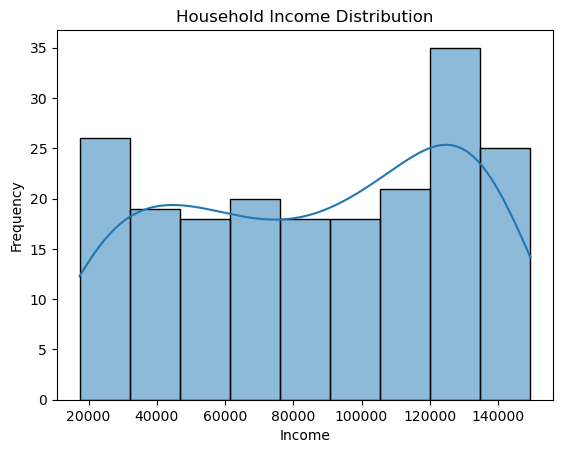

In [10]:
plt.figure()

sns.histplot(df["Household_Income"], kde=True)

plt.title("Household Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.show()

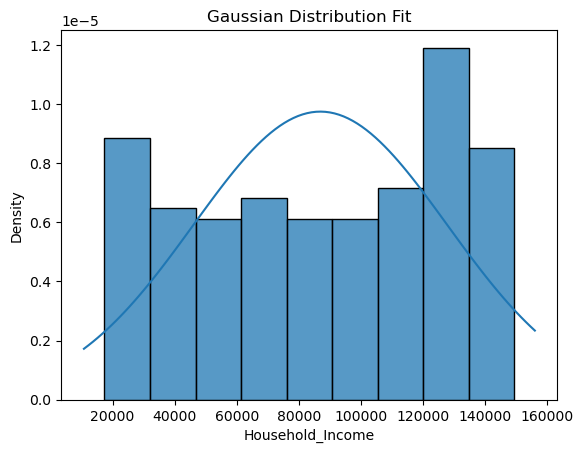

In [11]:
plt.figure()

sns.histplot(df["Household_Income"], stat="density")

mean = df["Household_Income"].mean()
std = df["Household_Income"].std()

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = norm.pdf(x, mean, std)

plt.plot(x, p)

plt.title("Gaussian Distribution Fit")

plt.show()

In [12]:
income_skewness = skew(df["Household_Income"])
income_kurtosis = kurtosis(df["Household_Income"])

print("Skewness:", income_skewness)
print("Kurtosis:", income_kurtosis)

Skewness: -0.16822060664535943
Kurtosis: -1.2943295459612423


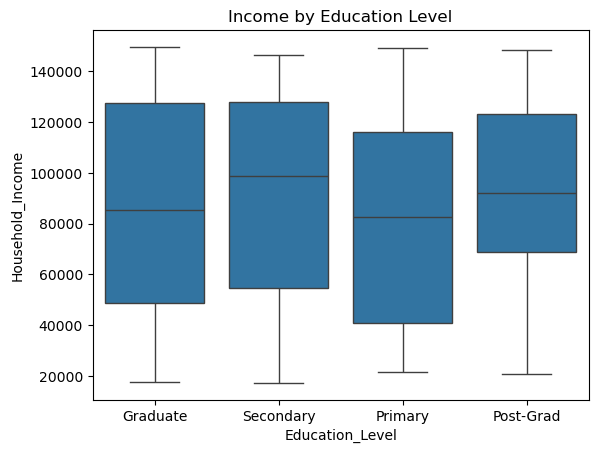

In [13]:
plt.figure()

sns.boxplot(x="Education_Level", y="Household_Income", data=df)

plt.title("Income by Education Level")

plt.show()

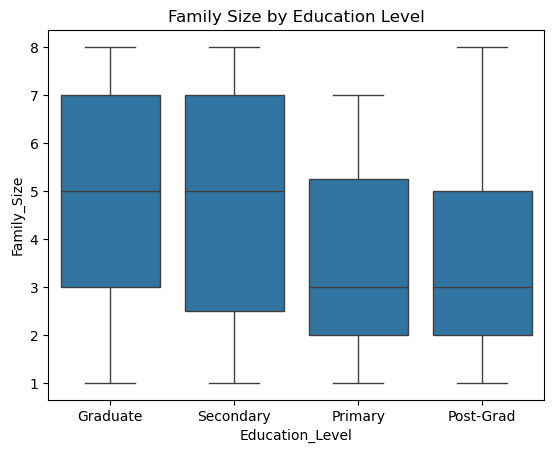

In [14]:
plt.figure()

sns.boxplot(x="Education_Level", y="Family_Size", data=df)

plt.title("Family Size by Education Level")

plt.show()

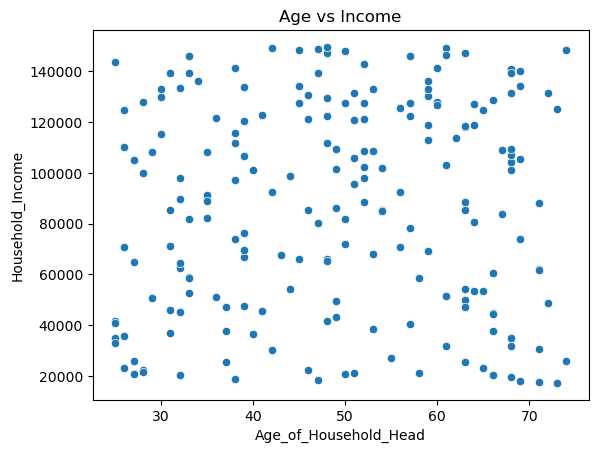

In [15]:
plt.figure()

sns.scatterplot(x="Age_of_Household_Head", y="Household_Income", data=df)

plt.title("Age vs Income")

plt.show()

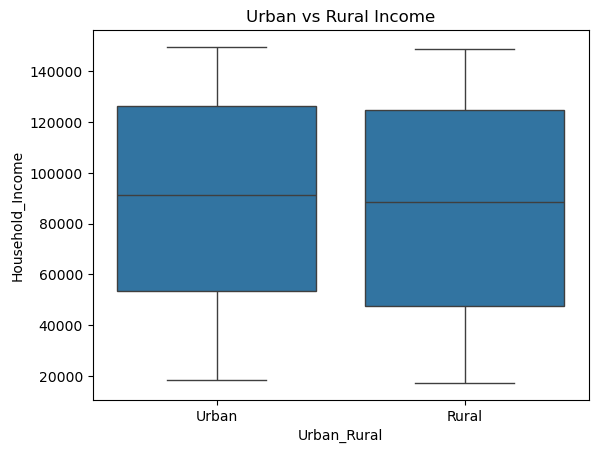

In [16]:
plt.figure()

sns.boxplot(x="Urban_Rural", y="Household_Income", data=df)

plt.title("Urban vs Rural Income")

plt.show()